Authors:

*Ben Finkelshtein ben.finkelshtein@kellogg.ox.ac.uk*, and *Federico Barbero federico.barbero@cs.ox.ac.uk*.


Based off of a notebook by Cristian Bodnar, Iulia Duta, and Paul Scherer.

#Practical 2: Advanced GNNs 😀


Welcome to practical 2 of the GDL course. In the first practical, we looked at some fundamental GNN concepts. In this practical we will look at some slightly more involved topics:

- Moving to graph-level prediction and the challenges of batching observations that are graphs.
- Studying the expressive power of GNNs on different graphs. 

While doing so, we will also familiarise ourselves with the various challenges involved in implementing GNNs, and their expressivity. We note that expressivity is currently a VERY hot topic in the GNN literature, with many recent highlighted papers involving the concepts we will touch upon today!

In [1]:
#@title
from IPython.display import HTML
HTML('<iframe width="560" height="315" src="https://www.youtube.com/embed/AJG1K0dbpes" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" allowfullscreen></iframe>')

/usr/local/lib/python3.8/dist-packages/IPython/core/display.py:701: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


# Installation

In [2]:
#@title [RUN] Install required libraries
!pip install torch==1.12.1+cu113 torchvision==0.13.1+cu113 torchaudio==0.12.1 --extra-index-url https://download.pytorch.org/whl/cu113

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/, https://download.pytorch.org/whl/cu113
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 GB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.4/23.4 MB 69.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 65.2 MB/s eta 0:00:00
  Attempting uninstall: torch
    Found existing installation: torch 1.13.1+cu116
    Uninstalling torch-1.13.1+cu116:
      Successfully uninstalled torch-1.13.1+cu116
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.14.1+cu116
    Uninstalling torchvision-0.14.1+cu116:
      Successfully uninstalled torchvision-0.14.1+cu116
  Attempting uninstall: torchaudio
    Found existing installation: torchaudio 0.13.1+cu116
    Uninstalling torchaudio-0.13.1+cu116:
      Successfully uninstalled torchaudio-0.13.1+cu116
ERROR: pip's dependency resolver does not currently take into account al

In [3]:
!pip install networkx

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-1.12.1+cu113.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-1.12.1+cu113.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

!pip install mycolorpy
!pip install colorama

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 60.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 34.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 KB 6.3 MB/s eta 0:00:00
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Preparing metadata (setup.py) ... done
  Created wheel for mycolorpy: filename=mycolorpy-1.5.1-py3-none-any.whl size=3871 sha256=8eac23998450b0f4b73ba4e42ecf918fb522bb19bf7839e386a639ea0d94eb28
  Stored in directory: /root/.cache/pip/wheels/de/f6/20/d5f4361bb07416d18914807370aac98a7581f644cf18362df0
Successfully built mycolorpy
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simpl

In [4]:
#@title [RUN] Import modules
import numpy as np
import seaborn as sns
import math
import itertools
import scipy as sp
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch_geometric
from torch_geometric.datasets import Planetoid, ZINC, GNNBenchmarkDataset
from torch_scatter import scatter_mean, scatter_max, scatter_sum
from torch_geometric.utils import to_dense_adj
from torch.nn import Embedding

import pdb

#for nice visualisations
import networkx as nx
import matplotlib.pyplot as plt

from mycolorpy import colorlist as mcp
import matplotlib.cm as cm

from typing import Mapping, Tuple, Sequence, List
import colorama

import scipy.linalg
from scipy.linalg import block_diag

In [5]:
# @title [RUN] Helper functions for plots and visualisations

####### VISUALISATIONS #######

def draw_one_graph(ax, edges, label=None, node_emb=None, layout=None, special_color=False):
    """draw a graph with networkx based on adjacency matrix (edges)
    graph labels could be displayed as a title for each graph
    node_emb could be displayed in colors
    """
    graph = nx.Graph()
    edges = zip(edges[0], edges[1])
    graph.add_edges_from(edges)
    node_pos = layout(graph)
    #add colors according to node embeding
    if (node_emb is not None) or special_color:
        color_map = []
        node_list = [node[0] for node in graph.nodes(data = True)]
        for i,node in enumerate(node_list):
            #just ignore this branch
            if special_color:
                if len(node_list) == 3:
                    crt_color = (1,0,0)
                elif len(node_list) == 5:
                    crt_color = (0,1,0)
                elif len(node_list) == 4:
                    crt_color = (1,1,0)
                else:
                  special_list = [(1,0,0)] * 3 + [(0,1,0)] * 5 + [(1,1,0)] * 4
                  crt_color = special_list[i]
            else:
                crt_node_emb = node_emb[node]
                #map float number (node embeding) to a color
                crt_color = cm.gist_rainbow(crt_node_emb, bytes=True)
                crt_color = (crt_color[0]/255.0, crt_color[1]/255.0, crt_color[2]/255.0, crt_color[3]/255.0)
            color_map.append(crt_color)
      
        nx.draw_networkx_nodes(graph,node_pos, node_color=color_map,
                        nodelist = node_list, ax=ax)
        nx.draw_networkx_edges(graph, node_pos, ax=ax)
        nx.draw_networkx_labels(graph,node_pos, ax=ax)
    else:
        nx.draw_networkx(graph, node_pos, ax=ax)

def gallery(graphs, labels=None, node_emb=None, special_color=False, max_graphs=4, max_fig_size=(40, 10), layout=nx.layout.kamada_kawai_layout):
    ''' Draw multiple graphs as a gallery 
    Args:
      graphs: torch_geometrics.dataset object/ List of Graph objects
      labels: num_graphs
      node_emb: num_graphs* [num_nodes x num_ch]
      max_graphs: maximum graphs display
    '''
    num_graphs = min(len(graphs), max_graphs)
    ff, axes = plt.subplots(1, num_graphs,
                            figsize=max_fig_size,
                            subplot_kw={'xticks': [], 'yticks': []})
    if num_graphs == 1:
        axes = [axes]
    if node_emb is None:
        node_emb = num_graphs*[None]
    if labels is None:
        labels = num_graphs * [" "]


    for i in range(num_graphs):
        draw_one_graph(axes[i], graphs[i].edge_index.numpy(), labels[i], node_emb[i], layout, special_color)
        if labels[i] != " ":
            axes[i].set_title(f"Target: {labels[i]}", fontsize=28)
        axes[i].set_axis_off()
    plt.show()

def hash_node_embedings(node_emb):
  """ Hash the tensor representing nodes' features 
  to a number in [0,1] used to represent a color

  Args:
    node_emb: list of num_graphs arrays, each of dim (num_nodes x num_feats)
  Returns:
    list of num_graphs arrays in [0,1], each of dim (num_nodes) 
  """
  chunk_size_graph = [x.shape[0] for x in node_emb]
  start_idx_graph = [0] + list(itertools.accumulate(chunk_size_graph))[:-1]

  node_emb_flatten = np.concatenate(node_emb).mean(-1)

  min_emb = node_emb_flatten.min()
  max_emb = node_emb_flatten.max()
  node_emb_flatten = (node_emb_flatten-min_emb)/(max_emb-min_emb)

  #split in graphs again according to (start_idx_graph, chunk_size_graph)
  node_emb_hashed = [node_emb_flatten[i:i+l] for (i,l) in zip(start_idx_graph, chunk_size_graph)]
  return node_emb_hashed

####### PLOTS #######

def update_stats(training_stats, epoch_stats):
    """ Store metrics along the training
    Args:
      epoch_stats: dict containg metrics about one epoch
      training_stats: dict containing lists of metrics along training
    Returns:
      updated training_stats
    """
    if training_stats is None:
        training_stats = {}
        for key in epoch_stats.keys():
            training_stats[key] = []
    for key,val in epoch_stats.items():
        training_stats[key].append(val)
    return training_stats

def plot_stats(training_stats, figsize=(5, 5), name=""):
    """ Create one plot for each metric stored in training_stats
    """
    stats_names = [key[6:] for key in training_stats.keys() if key.startswith('train_')]
    f, ax = plt.subplots(len(stats_names), 1, figsize=figsize)
    if len(stats_names)==1:
        ax = np.array([ax])
    for key, axx in zip(stats_names, ax.reshape(-1,)):
        axx.plot(
            training_stats['epoch'],
            training_stats[f'train_{key}'],
            label=f"Training {key}")
        axx.plot(
            training_stats['epoch'],
            training_stats[f'val_{key}'],
            label=f"Validation {key}")
        axx.set_xlabel("Training epoch")
        axx.set_ylabel(key)
        axx.legend()
    plt.title(name)


def get_color_coded_str(i, color):
    return "\033[3{}m{}\033[0m".format(int(color), int(i))

def print_color_numpy(map, list_graphs):
    """ print matrix map in color according to list_graphs
    """
    list_blocks = []
    for i,graph in enumerate(list_graphs):
        block_i = (i+1)*np.ones((graph.num_nodes,graph.num_nodes))
        list_blocks += [block_i]
    block_color = block_diag(*list_blocks)
    
    map_modified = np.vectorize(get_color_coded_str)(map, block_color)
    print("\n".join([" ".join(["{}"]*map.shape[0])]*map.shape[1]).format(*[x for y in map_modified.tolist() for x in y]))
  

In the previous practical, you trained a Graph Neural Network for node-level prediction. Let's move to a graph-level task to understand **what changes you should make in the architecture** and **what are some limitations of classical models**. 

For this, we will use [ZINC](https://arxiv.org/abs/1610.02415). ZINC is a dataset for graph-regression. It contains about 12 000 molecular graphs with up to 38 nodes each and the task is to predict for each molecule the solubility (a scalar number).

Let's load the dataset using the [torch_geometric.dataset](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.ZINC) and check what it contains:

In [6]:
train_zinc_dataset = ZINC(root='', split='train', subset=True)
val_zinc_dataset = ZINC(root='', split='val', subset=True)
test_zinc_dataset = ZINC(root='', split='test', subset=True)

print(f"\nTrain examples: {len(train_zinc_dataset)}")
print(f"Val examples: {len(val_zinc_dataset)}")
print(f"Test examples: {len(test_zinc_dataset)}\n")

one_graph = train_zinc_dataset[0]

print(f"First graph contains {one_graph.x.shape[0]} nodes, each characterised by {one_graph.x.shape[1]} features")
print(f"Graph labels have shape: {one_graph.y.shape}")


Extracting ./molecules.zip
Processing...
Processing test dataset: 100%|██████████| 1000/1000 [00:00<00:00, 7621.46it/s]


Train examples: 10000
Val examples: 1000
Test examples: 1000

First graph contains 29 nodes, each characterised by 1 features
Graph labels have shape: torch.Size([1])



Done!


To store information about each graph, we create the following ` Graph` class. Note that, instead of storing an entire adjacency matrix to describe the graph structure, we will store it more efficiently as a list of edges of shape `[2, num_edges]`.  

Note: `*_zinc_dataset` loads above are not instances of Graph structure, but their structure [torch_geometric.Data](https://pytorch-geometric.readthedocs.io/en/latest/modules/data.html#torch_geometric.data.Data) is a lot similar to that one.



In [7]:
class Graph(object):
    def __init__(self, edge_index, x, y):
        """ Graph structure 
            for a mini-batch it will store a big (sparse) graph 
            representing the entire batch
        Args:
            x: node features  [num_nodes x num_feats]
            y: graph labels   [num_graphs]
            edge_index: list of edges [2 x num_edges]
        """
        self.edge_index = edge_index
        self.x = x.to(torch.float32)
        self.y = y
        self.num_nodes = self.x.shape[0]

    #ignore this for now, it will be useful for batching
    def set_batch(self, batch):
        """ list of ints that maps each node to the graph it belongs to
            e.g. for batch = [0,0,0,1,1,1,1]: the first 3 nodes belong to graph_0 while
            the last 4 belong to graph_1
        """
        self.batch = batch

    # this function return a sparse tensor
    def get_adjacency_matrix(self):
        """ from the list of edges create 
        a num_nodes x num_nodes sparse adjacency matrix
        """
        return torch.sparse.LongTensor(self.edge_index, 
                              # we work with a binary adj containing 1 if an edge exist
                              torch.ones((self.edge_index.shape[1])), 
                              torch.Size((self.num_nodes, self.num_nodes))
                              )

Note that the adjacency matrix (`self.get_adjacency_matrix()`) is stored as a sparse matrix (using `torch.sparse.LongTensor()`), for memory efficiency reasons. This means that, instead of the entire matrix, we will only store the indexes of the vertices and the value (weight) corresponding to each edge. This saves lots of memory in storing the tensors for which the majority of elements are zeros.

If you need to convert a sparse tensor `x` into a dense one you can use `x.to_dense()`. Moreover, many operations are directly supported for sparse tensors via [torch.sparse](https://pytorch.org/docs/stable/sparse.html) (e.g. `torch.sparse.mm()` that multiplies a sparse matrix with a sparse/dense matrix). Keep in mind that you should try to avoid densifying a matrix unless it is absolutely necessary.

Lets visualize the graphs using the `networkx` library. 

*Showing how to do this is out of the scope of this lab, so the function is entirely coded for you, but you can find out more about this from [here](https://networkx.org/documentation/stable/tutorial.html).*

<ipython-input-8-70bd61bc2dd1>:1: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  gallery([one_graph], labels=np.array([one_graph.y]), max_fig_size=(8,10))


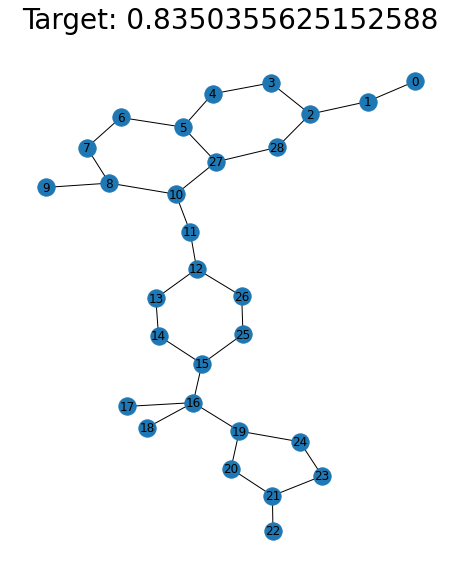

In [8]:
gallery([one_graph], labels=np.array([one_graph.y]), max_fig_size=(8,10))

# Mini-batching for graph data

Since we are now dealing with multiple graphs, we need to figure out how to store them in mini-batches, to be able to make the computation as efficient as possible. For some types of data, stacking samples in mini-batches is a trivial task. For example, images of $32\times32$ pixels are easy to batch because they have the same dimension (obtaining a tensor of dimension $batch\_{size}\times32\times32$). On the other hand, graphs come in different sizes with adjacency matrices of different shapes:

In [9]:
print(f'First graph : {train_zinc_dataset[0].x.shape} with adjacency {(train_zinc_dataset[0].num_nodes, train_zinc_dataset[0].num_nodes)}')
print(f'Second graph: {train_zinc_dataset[1].x.shape} with adjacency {(train_zinc_dataset[1].num_nodes, train_zinc_dataset[1].num_nodes)}')
print(f'Third graph : {train_zinc_dataset[2].x.shape} with adjacency {(train_zinc_dataset[2].num_nodes, train_zinc_dataset[2].num_nodes)}')


First graph : torch.Size([29, 1]) with adjacency (29, 29)
Second graph: torch.Size([26, 1]) with adjacency (26, 26)
Third graph : torch.Size([16, 1]) with adjacency (16, 16)


One solution for this is to create a single *sparse* graph as the union of all the graphs in the mini-batch as follow:

1. stack the features $x$ for all the nodes in all the graphs
2. stack the labels $y$ for all the nodes in all the graphs
3. stack all the adjacency matrices $A_i$ as diagonal blocks in the new adjacency matrix

This way, we will obtain a new graph containing $\sum_{i=1}^{B}|V_i|$ nodes, where $B$ is the batch_size and by $|V_i|$ we denote the number of nodes in graph $i$. Note that since **no** edges connect nodes from different graphs,  the  information propagation will not be affected by the way we store it.  

<center>
<img src="https://drive.google.com/uc?export=view&id=1RwI0CYA57S0OgLxgHgV6PBFNG9tnGvGR" width="500">
</center>

<center>
<img src="https://drive.google.com/uc?export=view&id=1Ux65wTJLXCfJ4TI4Up4mCHkaSja8NgrJ" width="500">
</center>


As you can see, the resulting matrix contains many zeros (sparse), thus our choice of storing the adjacency matrix as a sparse tensor can indeed bring us efficiency.

Until now, we have a way to store the graphs in a mini-batch such that they could be efficiently processed. 

However, we need to also be able to extract information from this structure, to recover the graphs that it contains. For this, we need to remember what initial graph each node belongs to.

We will do this by storing a list of indices `(self.batch)`, which map each node in the batch-graph to the initial graph it belong to. For example `batch=[0,0,0,1,1,2,2,2]` indicates that first 3 nodes belong to $G_0$, the next 2 nodes belong to $G_1$ and the last 3 nodes belong to $G_2$.



In [10]:
def create_mini_batch(graph_list: List[Graph]) -> Graph:
    """ Built a sparse graph from a batch of graphs
    Args:
        graph_list: list of Graph objects in a batch
    Returns:
        a big (sparse) Graph representing the entire batch
    """
    #insert first graph into the structure
    batch_edge_index = graph_list[0].edge_index
    batch_x = graph_list[0].x
    batch_y = graph_list[0].y
    batch_batch = torch.zeros((graph_list[0].num_nodes), dtype=torch.int64)

    nodes_count = graph_list[0].num_nodes

    #append the rest of the graphs to the structure
    for idx, graph in enumerate(graph_list[1:]):
        # concat the features
        batch_x = torch.cat((batch_x, graph.x))
        # concat the labels
        batch_y = torch.cat((batch_y, graph.y))

        # concat the adjacency matrix as a block diagonal matrix

        # here we have to modify the current graph edge index by adding 
        # to the row and column the number of nodes we have already 
        # added to the batch, this way when computing the sparse block matrix,
        # we position the nodes correctly 
        batch_edge_index = torch.cat((
            batch_edge_index, 
            torch.add(graph.edge_index, nodes_count))
        , dim=1)
        nodes_count += graph.num_nodes

        # create the array of indexes mapping nodes in the batch-graph
        # to the graph they belong to
        # specify the mapping between the new nodes and the graph they belong to (idx+1)

        # here we append a vector of [idx+1, idx+1,...] which has dimension graph.num_nodes
        # to our existing batch_batch vector to keep track of the nodes
        batch_batch = torch.cat((
            batch_batch, 
            torch.full((graph.num_nodes,), idx + 1)
        ))

    #create the big sparse graph 
    batch_graph = Graph(batch_edge_index, batch_x, batch_y)
    #attach the index array to the Graph structure
    batch_graph.set_batch(batch_batch)
    return batch_graph

Batch number_of_nodes: 12
Batch features shape: torch.Size([12, 32])
Batch labels shape: torch.Size([3])
Batch adjacency: 
1 1 1 0 0 0 0 0 0 0 0 0
1 1 1 0 0 0 0 0 0 0 0 0
1 1 1 0 0 0 0 0 0 0 0 0
0 0 0 1 1 1 1 1 0 0 0 0
0 0 0 1 0 1 1 1 0 0 0 0
0 0 0 1 0 0 0 1 0 0 0 0
0 0 0 1 0 0 0 0 0 0 0 0
0 0 0 1 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 1 0 0
0 0 0 0 0 0 0 0 0 0 1 0
0 0 0 0 0 0 0 0 0 0 0 1
0 0 0 0 0 0 0 0 1 0 0 0


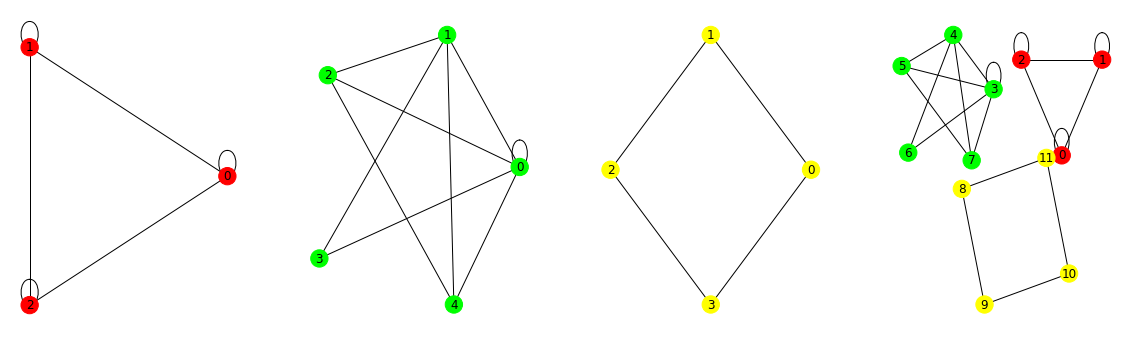

And we also have access to which graph each node belongs to tensor([0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2])



In [11]:
#@title Visualize the mini-batching for a small list of batch_size=3 graphs

# 3 random custom-designed graphs for visualisations
graph1 = Graph(x=torch.rand((3,32)), 
               y=torch.rand((1)), 
               edge_index=torch.tensor([[0,0,0,1,1,1,2,2,2],[0,1,2,0,1,2,0,1,2]]))
graph2 = Graph(x=torch.rand((5,32)), 
               y=torch.rand((1)), 
               edge_index=torch.tensor([[0,0,0,0,0,1,1,1,2,1,2,3,4], [0,1,2,3,4,2,3,4,4,0,0,0,0]]))
graph3 = Graph(x=torch.rand((4,32)),
               y=torch.rand((1)), 
              edge_index=torch.tensor([[0,1,2,3],[1,2,3,0]]))
list_graphs = [graph1, graph2, graph3]

# create a mini-batch from these 3 graphs
batch_sample = create_mini_batch(list_graphs)

# show statistics about the new graph built from this batch of graphs
print(f"Batch number_of_nodes: {batch_sample.num_nodes}")
print(f"Batch features shape: {batch_sample.x.shape}")
print(f"Batch labels shape: {batch_sample.y.shape}")

print(f"Batch adjacency: ")
print_color_numpy(batch_sample.get_adjacency_matrix().to_dense().numpy(), list_graphs)

gallery([graph1, graph2, graph3, batch_sample], max_fig_size=(20,6), special_color=True)
print(f"And we also have access to which graph each node belongs to {batch_sample.batch}\n")


As we can see the adjacency matrix above is in a *block diagonal* structure. With this structure, effectively each graph is independent from the other - exactly what we want for batching! We would not want the representations of a graph to affect the representation of a different graph. 

# Part 1: Graph Isomorphism Network:

In [12]:
# @title [RUN] Hyperparameters GIN 

BATCH_SIZE = 128 #@param {type:"integer"}
NUM_EPOCHS =   10#@param {type:"integer"}
HIDDEN_DIM =   64#@param {type:"integer"}
LR         = 0.001 #@param {type:"number"}

#you can add more here if you need

We will design a  Graph Neural Network model, similar to the one used on Cora, with the following modifications:
* graph-level prediction instead of node-level prediction
* regression instead of classification
* to obtain *provable more powerful architecture* $^\dagger$, we will go beyond GCN Layer and implement a [**GIN Layer**](https://arxiv.org/abs/1810.00826) instead.

$^\dagger$*we will rigurously define what it means in the last section of the Practical*.

One simple instantiation of GIN Layer processes the graph according to the following message passing equation, where $\epsilon_k$ is a learnable scalar

\begin{equation}
X^{k+1}= \text{MLP}_k\big(AX^k + (1+\epsilon_k)X^k\big)
\end{equation}

### 💻 **Task 1:** Fill in the missing part that implements the core message passing equation shown above.

Tip: Make sure you use `torch.spmm` when multiplying with the adjacency matrix. 

In [14]:
from torch_geometric.nn import MLP
from torch.sparse import mm as spmm

class GINLayer(nn.Module):
    """A single GIN layer, implementing MLP(AX + (1+eps)X)"""
    def __init__(self, in_feats: int, out_feats: int, hidden_dim: int, eps: float=0.0):
        super(GINLayer, self).__init__()
        # ============ YOUR CODE HERE =============
        self.mlp = MLP([in_feats, hidden_dim, out_feats])
        self.eps = torch.nn.Parameter(torch.tensor(eps))
        # =========================================

    def forward(self, x, adj_sparse): 
        # ============ YOUR CODE HERE =============
        out = self.mlp(spmm(adj_sparse, x) + (1 + self.eps) * x)
        # =========================================
        return out

Using the above GIN Layer, let's design a neural network with `num_layers` GINLayers, to solve the graph-regression task

### 💻 **Task 2:** Creates graph-representations from node-representations

In [21]:
from torch.nn.modules.linear import Linear
from torch_geometric.nn import global_mean_pool
from torch_scatter import scatter
class SimpleGIN(nn.Module):
    """ 
    A Graph Neural Network containing GIN layers 
    as in https://arxiv.org/abs/1810.00826 
    The readout function used to obtain graph-lvl representations
    is just the sum of the nodes in the graph

    Args:
        input_dim (int): Dimensionality of the input feature vectors
        output_dim (int): Dimensionality of the output softmax distribution
        num_layers (int): Number of layers
    """
    def __init__(self, input_dim, output_dim, hidden_dim, num_layers=2, eps=0.0, 
                 molecular=True):
        super(SimpleGIN, self).__init__()
        self.num_layers = num_layers # please select num_layers>=2
        self.molecular = molecular
        # nodes in ZINC dataset are characterised by one integer (atom category)
        # we will create embeddings from the categorical features using nn.Embedding
        if self.molecular:
            self.embed_x = Embedding(28, hidden_dim)
        else:
            self.embed_x = Linear(input_dim, hidden_dim)

        # instead of nn.Linear as in SimpleMLP model, 
        # now we have (num_layers) GINLayer(s), each with different parameters
        # ============ YOUR CODE HERE =============
        self.layers = nn.ModuleList([GINLayer(hidden_dim, 
                                              output_dim if i==num_layers-1 else hidden_dim,
                                              hidden_dim,
                                              eps) 
                                    for i in range(num_layers)])
        self.num_layers = num_layers
        self.act_fn = nn.ReLU()
        # =========================================
    
    def forward(self, graph):
        adj_sparse = graph.get_adjacency_matrix()
        if self.molecular:
            x = self.embed_x(graph.x.long()).squeeze(1)
        else:
            x = self.embed_x(graph.x)

        # graph-level representations are obtain by (scatter) pooling info from the nodes
        # ============ YOUR CODE HERE =============
        # use a ReLU activation for each layer, except the final one
        for i, layer in enumerate(self.layers):
            x = layer(x, adj_sparse)
            if i < self.num_layers - 1:
                x = self.act_fn(x)
        # graph-level representations are obtain by pooling info from the nodes
        y_hat = scatter(x, graph.batch, dim=0, reduce='mean')

        # =========================================

        y_hat = y_hat.squeeze(-1)
        #return also the final node embeddings x (for visualisations)
        return y_hat, x

Since now we have a proper graph network to play with, let's check if our mini-batch implementation is correct. For this, we provide an unit test checking that runing the code on individual graphs or directly on an entire batch provides the same results: 

In [16]:
#@title [RUN] Unit test for mini-batch implementation
def unit_test_mini_batch(batch):
  model = SimpleGIN(input_dim=batch[0].x.size()[-1], output_dim=1, hidden_dim=HIDDEN_DIM, num_layers=4)
  model.eval()
  graph_batch = create_mini_batch(batch)
  out_batch, _ = model(graph_batch)

  for i in range(BATCH_SIZE):
    batch_i = create_mini_batch([batch[i]])
    out_i, node_emb_i = model(batch_i)
    assert(np.abs(out_i.detach().numpy() - out_batch[i].detach().numpy()).mean() <1e-5 )
  print("Congrats 😊 !! Everything seems all right!")

In [17]:
#@title Run unit test for mini-batch implementation
batch = train_zinc_dataset[:BATCH_SIZE]
unit_test_mini_batch(batch)

Congrats 😊 !! Everything seems all right!


In [18]:
def train(dataset, model, optimiser, epoch, loss_fct, metric_fct, print_every):
    """ Train model for one epoch 
    """
    model.train()
    num_iter = int(len(dataset)/BATCH_SIZE)
    for i in range(num_iter):
        batch_list = dataset[i*BATCH_SIZE:(i+1)*BATCH_SIZE]
        batch = create_mini_batch(batch_list)
        optimiser.zero_grad()
        y_hat, _ = model(batch)
        loss = loss_fct(y_hat.float(), batch.y.float())
        metric = metric_fct(y_hat.float(), batch.y.float())
        loss.backward()
        optimiser.step() 
        if (i+1) % print_every == 0:
          print(f"Epoch {epoch} Iter {i}/{num_iter}",
                    f"Loss train {loss.data}; Metric train {metric.data}")
    return loss, metric

def evaluate(dataset, model, loss_fct, metrics_fct):
    """ Evaluate model on dataset
    """
    model.eval()
    # be careful in practice, as doing this way we will lose some 
    # examples from the validation split, when len(dataset)%BATCH_SIZE != 0
    # think about how can you fix this!
    num_iter = int(len(dataset)/BATCH_SIZE)
    metrics_eval = 0
    loss_eval = 0
    for i in range(num_iter):
        batch_list = dataset[i*BATCH_SIZE:(i+1)*BATCH_SIZE]
        batch = create_mini_batch(batch_list)
        y_hat, _ = model(batch)
        metrics = metrics_fct(y_hat, batch.y)
        loss = loss_fct(y_hat, batch.y)

        metrics_eval += metrics.data
        loss_eval += loss.data
    metrics_eval /= num_iter
    loss_eval /= num_iter
    return loss_eval, metrics_eval

In [26]:
def train_eval(model, train_dataset, val_dataset, test_dataset, 
               loss_fct, metric_fct, print_every=1):
    """ Train the model for NUM_EPOCHS epochs
    """
    #Instantiatie our optimiser
    optimiser = optim.Adam(model.parameters(), lr=LR)
    training_stats = None

    #initial evaluation (before training)
    val_loss, val_metric = evaluate(val_dataset, model, loss_fct, metric_fct)
    train_loss, train_metric = evaluate(train_dataset[:BATCH_SIZE], model, 
                                        loss_fct, metric_fct)
    epoch_stats = {'train_loss': train_loss.detach(),
                   'val_loss': val_loss.detach(),
                   'train_metric': train_metric.detach(),
                   'val_metric': val_metric.detach(),'epoch':0}
    training_stats = update_stats(training_stats, epoch_stats)

    for epoch in range(NUM_EPOCHS):
        if isinstance(train_dataset, list):
            random.shuffle(train_dataset)
        else:
            train_dataset.shuffle()
        train_loss, train_metric = train(train_dataset, model, optimiser, epoch, 
                                        loss_fct, metric_fct, print_every)
        val_loss, val_metric = evaluate(val_dataset, model, loss_fct, metric_fct)
        print(f"[Epoch {epoch+1}]",
                    f"train loss: {train_loss:.3f} val loss: {val_loss:.3f}",
                    f"train metric: {train_metric:.3f} val metric: {val_metric:.3f}"
              )
        # store the loss and the computed metric for the final plot
        epoch_stats = {'train_loss': train_loss.detach(),
                       'val_loss': val_loss.detach(), 
                      'train_metric': train_metric.detach(),
                       'val_metric': val_metric.detach(), 
                      'epoch':epoch+1}
        training_stats = update_stats(training_stats, epoch_stats)

    test_loss, test_metric = evaluate(test_dataset, model,  loss_fct, metric_fct)
    print(f"Test metric: {test_metric:.3f}")
    return training_stats

Now it's time to train our model and enjoy the results. Make sure to check that the train loss is decreasing to at least ~0.5!

[Epoch 1] train loss: 0.774 val loss: 1.721 train metric: 0.774 val metric: 1.721
[Epoch 2] train loss: 0.582 val loss: 1.495 train metric: 0.582 val metric: 1.495
[Epoch 3] train loss: 0.532 val loss: 1.419 train metric: 0.532 val metric: 1.419
[Epoch 4] train loss: 0.480 val loss: 1.448 train metric: 0.480 val metric: 1.448
[Epoch 5] train loss: 0.470 val loss: 1.480 train metric: 0.470 val metric: 1.480
[Epoch 6] train loss: 0.472 val loss: 1.458 train metric: 0.472 val metric: 1.458
[Epoch 7] train loss: 0.506 val loss: 1.328 train metric: 0.506 val metric: 1.328
[Epoch 8] train loss: 0.460 val loss: 1.336 train metric: 0.460 val metric: 1.336
[Epoch 9] train loss: 0.450 val loss: 1.333 train metric: 0.450 val metric: 1.333
[Epoch 10] train loss: 0.428 val loss: 1.283 train metric: 0.428 val metric: 1.283
[Epoch 11] train loss: 0.429 val loss: 1.297 train metric: 0.429 val metric: 1.297
[Epoch 12] train loss: 0.438 val loss: 1.319 train metric: 0.438 val metric: 1.319
[Epoch 13] tr

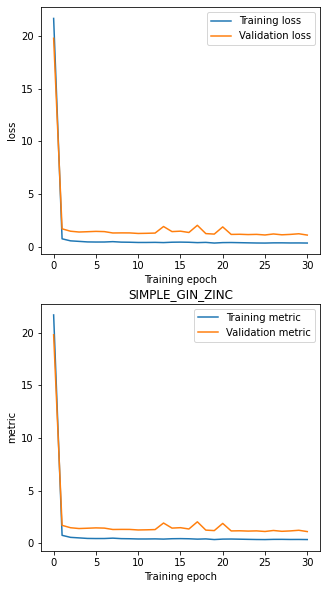

In [20]:
#Train GIN model:
model_simple_gin = SimpleGIN(input_dim=train_zinc_dataset.x.size()[-1],
                             output_dim=1, hidden_dim=HIDDEN_DIM, num_layers=4,
                             eps=0.1)
train_stats_simple_gin_zinc = train_eval(model_simple_gin, train_zinc_dataset, val_zinc_dataset, 
                                         test_zinc_dataset, loss_fct=F.mse_loss, 
                                         metric_fct=F.mse_loss, print_every=150)
plot_stats(train_stats_simple_gin_zinc, name='SIMPLE_GIN_ZINC', figsize=(5, 10))

The full GIN architecture, as introduced in the original [paper](https://arxiv.org/pdf/1810.00826.pdf), does not use only the final output for predictions. Instead, it creates a graph representation from the representation of all the intermediate layers:

\begin{equation}
h_G = CONCAT\big(\oplus_{v \in G}\{h_v^{(k)}\}| k=0,1..(K-1) \big)
\end{equation}

where $\oplus_{v \in G}\{h_v^{(k)}\}$ represents the graph-level representations at layer $k$, obtained by summing the representations from all the nodes $v \in G$

\\

### 💻 **Task 3:** Implement the entire architecture as described above.

In [22]:
class GIN(nn.Module):
    """ 
    A Graph Neural Network containing GIN layers 
    as in https://arxiv.org/abs/1810.00826 
    The readout function used to obtain graph-lvl representations
    aggregate pred from multiple layers (as in JK-Net)

    Args:
    input_dim (int): Dimensionality of the input feature vectors
    output_dim (int): Dimensionality of the output softmax distribution
    num_layers (int): Number of layers
    """
    def __init__(self, input_dim, output_dim, hidden_dim, num_layers=2, eps=0.0, \
                 molecular=True):
        super(GIN, self).__init__()
        self.num_layers = num_layers #please select num_layers >=1
        self.molecular = molecular
        # nodes in ZINC dataset are characterised by one integer (atom category)
        # we will create embeddings from the categorical features using nn.Embedding
        if self.molecular:
            self.embed_x = Embedding(28, hidden_dim)
        else:
            self.embed_x = Linear(input_dim, hidden_dim)

        # ============ YOUR CODE HERE =============
        # should be the same as before (an nn.ModuleList of GINLayers)
        self.layers = nn.ModuleList([GINLayer(hidden_dim, 
                                              hidden_dim,
                                              hidden_dim,
                                              eps) 
                                    for i in range(num_layers - 1)])
        self.num_layers = num_layers
        self.act_fn = nn.ReLU()

        # layer to compute prediction from the concatenated intermediate representations
        self.pred_layers = Linear(hidden_dim * num_layers, output_dim)
        # =========================================

    def forward(self, graph):
        adj_sparse = graph.get_adjacency_matrix()
        if self.molecular:
            x = self.embed_x(graph.x.long()).squeeze(1)
        else:
            x = self.embed_x(graph.x)

        # ============ YOUR CODE HERE ============= 
        # perform the forward pass with the new readout function 
        # use a ReLU activation for each layer, except the final one 
        xs = [x]
        for i, layer in enumerate(self.layers):
            x = layer(x, adj_sparse)
            if i < self.num_layers - 1:
                x = self.act_fn(x)
            xs.append(x)

        # Intermediate graph embeddings
        ys = [scatter(x, graph.batch, dim=0, reduce='mean') for x in xs]

        # Compute predictions for each graph
        y_hat = self.pred_layers(torch.cat(ys, dim=1))
        y_hat = y_hat.squeeze(-1)

        # Final node embeddings
        x = torch.cat(xs, dim=1)

        # =========================================
        # return also the final node embeddings (for visualisations)
        return y_hat, x

[Epoch 1] train loss: 0.576 val loss: 1.508 train metric: 0.576 val metric: 1.508
[Epoch 2] train loss: 0.551 val loss: 1.504 train metric: 0.551 val metric: 1.504
[Epoch 3] train loss: 0.525 val loss: 1.433 train metric: 0.525 val metric: 1.433
[Epoch 4] train loss: 0.516 val loss: 1.336 train metric: 0.516 val metric: 1.336
[Epoch 5] train loss: 0.514 val loss: 1.331 train metric: 0.514 val metric: 1.331
[Epoch 6] train loss: 0.501 val loss: 1.320 train metric: 0.501 val metric: 1.320
[Epoch 7] train loss: 0.489 val loss: 1.312 train metric: 0.489 val metric: 1.312
[Epoch 8] train loss: 0.471 val loss: 1.280 train metric: 0.471 val metric: 1.280
[Epoch 9] train loss: 0.478 val loss: 1.322 train metric: 0.478 val metric: 1.322
[Epoch 10] train loss: 0.476 val loss: 1.279 train metric: 0.476 val metric: 1.279
[Epoch 11] train loss: 0.464 val loss: 1.282 train metric: 0.464 val metric: 1.282
[Epoch 12] train loss: 0.465 val loss: 1.319 train metric: 0.465 val metric: 1.319
[Epoch 13] tr

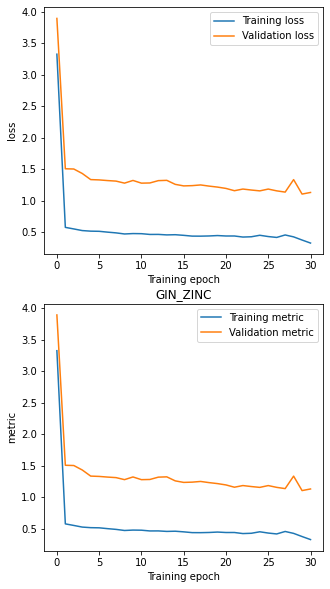

In [25]:
#Train GIN model:
model_gin = GIN(input_dim=train_zinc_dataset.x.size()[-1], output_dim=1,
                hidden_dim=HIDDEN_DIM, num_layers=4, eps=0.1)
train_stats_gin_zinc = train_eval(model_gin, train_zinc_dataset, val_zinc_dataset, 
                                  test_zinc_dataset, loss_fct=F.mse_loss, 
                                  metric_fct=F.mse_loss, print_every=150)
plot_stats(train_stats_gin_zinc, name='GIN_ZINC', figsize=(5, 10))

# Part 2: Expressive Power of Graph Neural Networks



You should be already confident that Graph Neural Networks represents powerful tools to process graph-data. However, there are some theoretically proven limitations that you should be aware of. From now on, your goal in this practical will be to **understand and overcome these limitations**.

In the following, we will look at 2 hard to distinguish  graphs and try to understand what are the problems that GNNs are not able to solve and why this happens.

In [27]:
#@title [RUN] Hard to distinguish graphs
def gen_hard_graphs_WL():
  """maybe change with something smarter.
  are these graphs somewhere?
  """
  
  x1 = torch.ones((10,1))
  edge_index1 = torch.tensor([[1, 1, 2, 2, 3, 3, 3, 4, 4, 5, 5, 6, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10],
                 [2, 5, 1, 3, 2, 4, 6, 3, 5, 1, 4, 3, 7, 10, 6, 8, 7, 9, 8, 10, 6, 9]])-1
  y1 = torch.tensor([1])

  x2 = torch.ones((10,1))
  edge_index2 = torch.tensor([[1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10],
                 [2, 6, 1, 3, 7, 2, 4, 10, 3, 5, 4, 6, 1, 5, 2, 8, 7, 9, 8, 10, 3, 9]])-1
  y2 =  torch.tensor([2])  

  graph1 = Graph(x=x1, edge_index=edge_index1, y=y1)
  graph2 = Graph(x=x2, edge_index=edge_index2, y=y2)
  return [graph1, graph2]

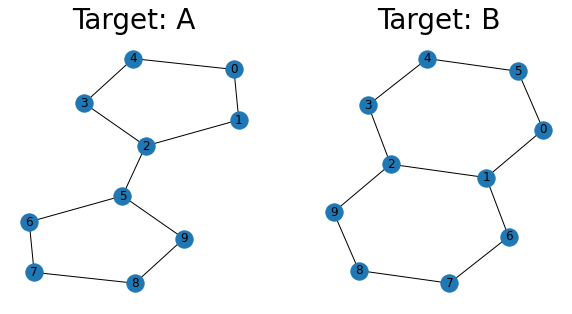

In [28]:
hard_graphs = gen_hard_graphs_WL()
gallery(hard_graphs, labels=["A","B"], max_fig_size=(10,5))

Let's try to encode these graphs using our GIN Neural Network.

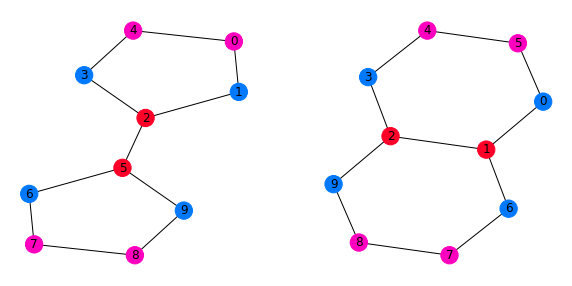

In [30]:
hard_batch = create_mini_batch(hard_graphs)
out, node_emb = model_simple_gin(hard_batch)

#split node_emb from batch into separate graphs
node_emb = node_emb.detach().numpy()
node_emb_split=[node_emb[:hard_graphs[0].num_nodes], node_emb[hard_graphs[0].num_nodes:]]

#encode node representation into an int in [0,1] denoting the color
node_emb_split = hash_node_embedings(node_emb_split)


gallery(hard_graphs, node_emb=node_emb_split, max_fig_size=(10,5))


In the visualisation from above, the colors indicate the nodes embedings, as predicted by the model. Remember from the course that, to obtain a graph-level representation, we pool the nodes embedings using a *permutation invariant* function. This means that the multisets of colors determine the graph embeding. More exactly, if two graphs are encoded using the same multisets of colors, the final graph-representation will be the same.
This means that from the graph-level perspective the 2 graphs shown above are the same. However, for a human, it is obvious that this is not true.

**Why this is happening ❓**

Let's look at how the node embedings are computed by a 5-layer GNN.



<!-- <center> -->
<img src="https://drive.google.com/uc?export=view&id=1Jt6zJVApmgS9VFbcKpzxOoBtrxos55iu" width="1000">
<!-- </center> -->

If we are looking into how the computational network looks like for the two graphs in 5 steps, we observe that they essentially looks very similar. The **important** difference that we are able to spot, while the GNNs are not, is that, after 5 layers of propagation, in one graph (left) we reach the same note from where we've started, while in the other graph (right) we reach a different one. Since from the structure persective the 2 nodes are the same, the GNN will encode them the same without realising the difference between them. 

In the next section we will try to find how can we alleviate this and what could be the practical implications this problem raise.

# Improving the expressive power

As we have seen in the example above, GIN (and MPNNs in general) cannot distinguih any pair of non-isomorphic graphs. Based on this, we can devise a hierarchy of GNN models based on what pairs of graphs they can or cannot distinguish. 

**Definition.** *We say that a GNN model B is strictly more powerful than another model A if B can distinguish all the pairs of attributed graphs that A can distinguish and there exists a pair of attributed graphs that B can distiguish but A cannot.*

In this section, we are going to build a GNN model that is more powerful than GIN and design a synthetic task on which this can be evaluated emprically. Then, you will also be asked to prove mathematically that your model is indeed more powerful.

### 💻**Task 4:** Construct a graph classification or regression task where a model with superior expressive power should do better than GIN.

Hint: Try to find more examples of pairs of graphs that GIN cannot distiguish and generalise them into a dataset.

We recommend building upon the latter functions:
* `generate_graph_1` - Generates the first base graph
* `generate_graph_2` - Generates the second base graph such that it is $1$-WL indistinguishable from graph 1 
* `manipulate_base_graphs` - Manipulates the two base graphs to construct a dataset of graphs such that every graph in class $1$ has a pair in class $2$ such that the two are $1$-WL indistinguishable 

The idea is that `generate_graph_1` will generate a family of graphs $\mathsf{G}_1$ and `generate_graph_2` will generate the other family $\mathsf{G}_2$. Then for any $g_1 \in \mathsf{G}_1$ there exists a graph $g_2 \in \mathsf{G}_2$ such that $g_1$ and $g_2$ are indistinguishable under the $1$-WL test. 

Hint: You can start by looking at the example graphs above. Try to then think of a way of adding nodes and edges such that they still preserve the property of being indistinguishable from each other under the $1$-WL test. *Make sure that the graphs remain connected.*

In [31]:
# keep NUM_NODES to an even number
NUM_NODES = 6
HALF_NODES = int(NUM_NODES / 2)
DATASET_SIZE = 50

def generate_graph_1():
  x = torch.ones((NUM_NODES, 1))
  y = torch.tensor([0])
  # ============ YOUR CODE HERE =============
  edges = [torch.tensor([[0, 1],[1, 0]])]
  for i in range(0, NUM_NODES-2, 2):
      edges.append(torch.tensor([[i, i + 2],[i + 2, i]]))
  edges.append(torch.tensor([[NUM_NODES-1, 0],[0, NUM_NODES-1]]))
  for i in range(1, NUM_NODES-1, 2):
      edges.append(torch.tensor([[i, i + 2],[i + 2, i]]))
  edges.append(torch.tensor([[NUM_NODES-2, 1],[1, NUM_NODES-2]]))
  edge_index = torch.cat(edges, dim=1)

  # =========================================
  return x, y, edge_index

def generate_graph_2():
  x = torch.ones((NUM_NODES, 1))
  y = torch.tensor([1])
  # ============ YOUR CODE HERE =============
  edges = [torch.tensor([[0, 1],[1, 0]])]
  for i in range(0, NUM_NODES-2, 2):
      edges.append(torch.tensor([[i, i + 2],[i + 2, i]]))
  edges.append(torch.tensor([[NUM_NODES-1, 1],[1, NUM_NODES-1]]))
  for i in range(1, NUM_NODES-1, 2):
      edges.append(torch.tensor([[i, i + 2],[i + 2, i]]))
  edges.append(torch.tensor([[NUM_NODES-2, 0],[0, NUM_NODES-2]]))
  edge_index = torch.cat(edges, dim=1)
  # =========================================
  return x, y, edge_index

def manipulate_base_graphs(edge_index1, y1, edge_index2, y2):
  new_graphs = []
  # ============ YOUR CODE HERE =============
  for i in range(1, DATASET_SIZE):
      n = NUM_NODES + 4*i
      x = torch.ones((n, 1))
      new_edges = torch.tensor([[2,3,4,5,n-4,n-3,n-2,n-1],[n-4,n-3,n-2,n-1,2,3,4,5]])
      edge_index1 = torch.cat([edge_index1, new_edges], dim=1)
      edge_index2 = torch.cat([edge_index2, new_edges], dim=1)
      new_graphs.append(Graph(x=x, edge_index=edge_index1, y=y1))
      new_graphs.append(Graph(x=x, edge_index=edge_index2, y=y2))

  # =========================================
  return new_graphs

In [32]:
def generate_dataset():
  x1, y1, edge_index1 = generate_graph_1()
  x2, y2, edge_index2 = generate_graph_2()

  graphs = []

  graph1 = Graph(x=x1, edge_index=edge_index1, y=y1)
  graphs.append(graph1)

  graph2 = Graph(x=x2, edge_index=edge_index2, y=y2)
  graphs.append(graph2)

  return graphs + manipulate_base_graphs(edge_index1, y1, edge_index2, y2)

Visualize your dataset:

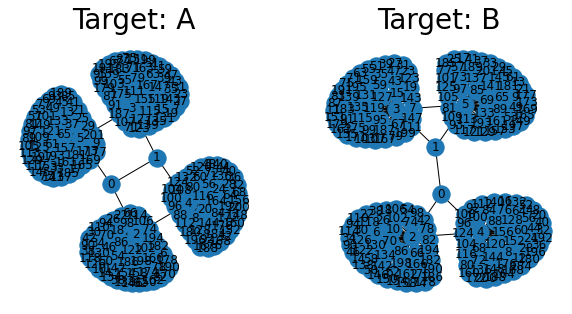

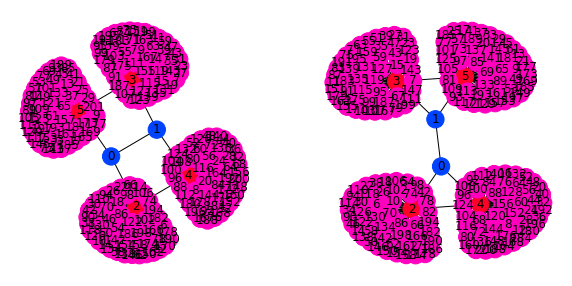

In [33]:
generated_dataset = generate_dataset()
visualized_dataset = generated_dataset[-2:]
gallery(visualized_dataset, labels=["A","B"], max_fig_size=(10,5))

hard_batch = create_mini_batch(visualized_dataset)
out, node_emb = model_simple_gin(hard_batch)

#split node_emb from batch into separate graphs
node_emb = node_emb.detach().numpy()
node_emb_split=[node_emb[:visualized_dataset[0].num_nodes], node_emb[visualized_dataset[0].num_nodes:]]

#encode node representation into an int in [0,1] denoting the color
node_emb_split = hash_node_embedings(node_emb_split)
gallery(visualized_dataset, node_emb=node_emb_split, max_fig_size=(10,5))

Split your dataset:

In [34]:
train_percentage, val_percentage = 0.4, 0.2
train_split = int(len(generated_dataset) * train_percentage)
val_split = int(len(generated_dataset) * val_percentage)

# training set 40% 
train_set = generated_dataset[:train_split] 

# validation set is 20%
val_set = generated_dataset[train_split:train_split + val_split] 

# test set is 40%
test_set = generated_dataset[train_split + val_split:]

print(f"Train graphs: {len(train_set)}")
print(f"Validation graphs: {len(val_set)}")
print(f"Test graphs: {len(test_set)}")
print(f"Total graphs: {len(generated_dataset)}")

Train graphs: 40
Validation graphs: 20
Test graphs: 40
Total graphs: 100


### The GIN on the task you have created

If you have done this correctly, you should expect an accuracy of $0.5$ which corresponds to random guessing.

In [35]:
def train_eval_test(model, train_data, val_data, test_data, name):
  train_stats = train_eval(model, train_data, val_data, 
                           test_data, loss_fct=F.mse_loss, 
                           metric_fct=F.mse_loss, print_every=20000)
  plot_stats(train_stats, name=name, figsize=(5, 10))

  correct = 0
  out, _ = model(create_mini_batch(test_data))
  for pred, label in zip(out, test_data):
    if round(pred.item()) == label.y.item():
      correct +=1
  acc = correct/len(out)
  print(f"Accuracy: {acc}")

[Epoch 1] train loss: 0.189 val loss: 0.251 train metric: 0.189 val metric: 0.251
[Epoch 2] train loss: 0.260 val loss: 0.255 train metric: 0.260 val metric: 0.255
[Epoch 3] train loss: 0.273 val loss: 0.261 train metric: 0.273 val metric: 0.261
[Epoch 4] train loss: 0.241 val loss: 0.258 train metric: 0.241 val metric: 0.258
[Epoch 5] train loss: 0.265 val loss: 0.253 train metric: 0.265 val metric: 0.253
[Epoch 6] train loss: 0.355 val loss: 0.270 train metric: 0.355 val metric: 0.270
[Epoch 7] train loss: 0.237 val loss: 0.263 train metric: 0.237 val metric: 0.263
[Epoch 8] train loss: 0.287 val loss: 0.250 train metric: 0.287 val metric: 0.250
[Epoch 9] train loss: 0.264 val loss: 0.318 train metric: 0.264 val metric: 0.318
[Epoch 10] train loss: 0.261 val loss: 0.261 train metric: 0.261 val metric: 0.261
[Epoch 11] train loss: 0.247 val loss: 0.285 train metric: 0.247 val metric: 0.285
[Epoch 12] train loss: 0.273 val loss: 0.267 train metric: 0.273 val metric: 0.267
[Epoch 13] tr

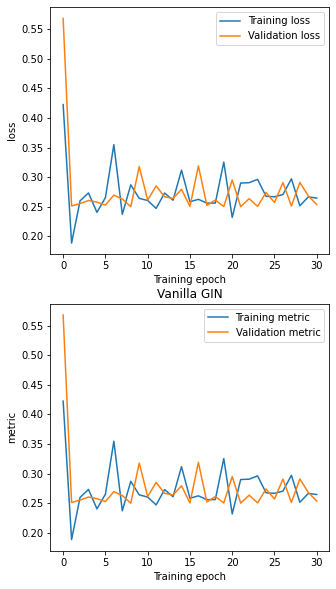

In [43]:
BATCH_SIZE = 5
model = GIN(input_dim=train_set[0].x.size()[-1],
                  output_dim=1, hidden_dim=HIDDEN_DIM, num_layers=4, eps=0.1,
                  molecular=False)
train_eval_test(model=model, train_data=train_set, val_data=val_set, test_data=test_set, name='Vanilla GIN')

### 💻**Task 5:** Think of a feature augmentation procedure that can increase the expressive power of GIN. Is GIN + Feature Augmentation better than GIN on your synthetic task? Explain your results.

How can you augment the initial graph features with additional information about the graph that could lead to higher discriminativity when applying a GIN model on top? Note that adding a boolean flag for the two different types of graphs is not a valid solution. In particular, think of a feature augmentation that will help you distinguish the synthetic graphs generated in the previous task.

Hint: You can try to look at quantities related to the adjacency matrix

In [44]:
def augment(graph):
  # ============ YOUR CODE HERE =============
  # Implement GIN with Feature Augmentation
  a = graph.get_adjacency_matrix()
  augmentation = torch.diagonal(spmm(a, spmm(a, a)).to_dense())
  augmentation = torch.reshape(augmentation, (-1, 1))
  # =========================================
  augmented_features = torch.cat((graph.x, augmentation), dim=1)
  return Graph(x=augmented_features, edge_index=graph.edge_index, y=graph.y.float())

augmented_train_set = [augment(graph) for graph in train_set]
augmented_val_set = [augment(graph) for graph in val_set]
augmented_test_set = [augment(graph) for  graph in test_set]

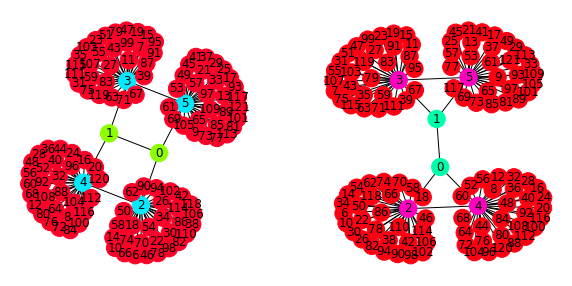

In [61]:
# Evaluates your model on your new dataset against GIN with Feature Augmentation
evaluation_dataset = augmented_val_set[-2:]
batch_hard_train_augmented = create_mini_batch(evaluation_dataset)
model = GIN(input_dim=batch_hard_train_augmented.x.size()[-1], output_dim=1, hidden_dim=HIDDEN_DIM, num_layers=4, eps=0.1, molecular=False)

hard_batch = create_mini_batch(evaluation_dataset)
out, node_emb = model(hard_batch)

#split node_emb from batch into separate graphs
node_emb = node_emb.detach().numpy()
node_emb_split=[node_emb[:evaluation_dataset[0].num_nodes], node_emb[evaluation_dataset[0].num_nodes:]]

#encode node representation into an int in [0,1] denoting the color
node_emb_split = hash_node_embedings(node_emb_split)
gallery(evaluation_dataset, node_emb=node_emb_split, max_fig_size=(10,5))

#### Feature Augmentation GIN

Remember that without feature augmentation we obtained an accuracy of $0.5$, corresponding to random guessing. The hope is that with the feature augmentation we can distinguish all of the graphs from each other and obtain an accuracy of $1.0$. 

[Epoch 1] train loss: 0.126 val loss: 0.099 train metric: 0.126 val metric: 0.099
[Epoch 2] train loss: 0.037 val loss: 0.433 train metric: 0.037 val metric: 0.433
[Epoch 3] train loss: 0.312 val loss: 0.198 train metric: 0.312 val metric: 0.198
[Epoch 4] train loss: 0.019 val loss: 0.179 train metric: 0.019 val metric: 0.179
[Epoch 5] train loss: 0.012 val loss: 0.144 train metric: 0.012 val metric: 0.144
[Epoch 6] train loss: 0.032 val loss: 0.080 train metric: 0.032 val metric: 0.080
[Epoch 7] train loss: 0.013 val loss: 0.117 train metric: 0.013 val metric: 0.117
[Epoch 8] train loss: 0.132 val loss: 0.056 train metric: 0.132 val metric: 0.056
[Epoch 9] train loss: 0.015 val loss: 0.009 train metric: 0.015 val metric: 0.009
[Epoch 10] train loss: 0.011 val loss: 0.109 train metric: 0.011 val metric: 0.109
[Epoch 11] train loss: 0.057 val loss: 0.098 train metric: 0.057 val metric: 0.098
[Epoch 12] train loss: 0.028 val loss: 0.021 train metric: 0.028 val metric: 0.021
[Epoch 13] tr

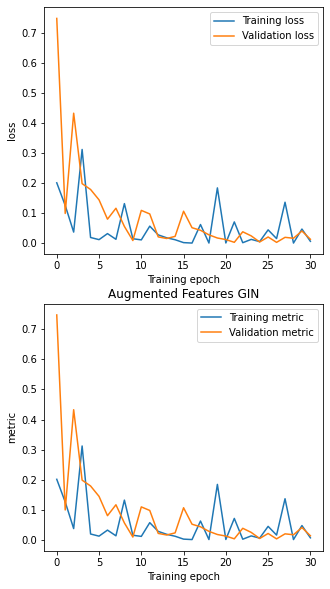

In [60]:
model = GIN(input_dim=augmented_train_set[0].x.size()[-1],
                  output_dim=1, hidden_dim=HIDDEN_DIM, num_layers=4, eps=0.1,
                  molecular=False)
train_eval_test(model=model, train_data=augmented_train_set, val_data=augmented_val_set,
                test_data=augmented_test_set, name='Augmented Features GIN')

### 💻**Bonus Task** Prove mathematically that GIN + Feature Augmentation is indeed strictly more powerful than vanilla GIN

Following our definition of more powerful, we will adopt a two steps approach. Firstly, prove that your model is at least as powerful as GIN (i.e. it can also distiguish all pairs that GIN can distinguish) and, secondly, that your model can also distinguish additional pairs compared to GIN. 

Let us write the local aggregation performed by GIN more abstractly as $x_v^{k+1} = f_{\text{GIN}}(x_v^k, \{\{ x_u^k \mid u \in \mathcal{N}(v)\}\})$, where $\{\{ ... \}\}$ denotes a multiset and $x_v^k$ the feature of node $v$ at layer $k$. Notice that GIN is maximally expressive when $f_{\text{GIN}}$ is injective because it allows it to map different neighbourhoods to different embeddings, which leads to higher discriminative power. We will use as a fact (i.e. no proof) that there exist a set of parameters that make $f_{\text{GIN}}$ injective. 

Thus, for the first part of the proof, prove the following steps:

**Step 1:** Denote by $x_v^k$ the features of node $v$ at layer $k$ of a GIN model with injective layers. Similarly, denote by $y_v^k$ the features of a second GIN model with injective layers and augmented features at $k=0$. Prove by induction that for any two nodes $v, u$ from two arbitrary graphs, if $y_v^k = y_u^k$, then $x_v^k = x_u^k$. 

**Step 2:** Prove that for any two graphs $\mathcal{G_1}, \mathcal{G_2}$, if $\{\{x_v^{k} \mid  v \in V_{\mathcal{G_1}} \}\} \neq \{\{x_u^{k} \mid  u \in V_{\mathcal{G_2}}\}\}$, then $\{\{y_v^{k} \mid  v \in V_{\mathcal{G_1}} \}\} \neq \{\{y_u^{k} \mid  u \in V_{\mathcal{G_2}}\}\}$. 

***Proof.*** 

*Step 1:*

$k=0:$ $y_v^0=x_v^0 \oplus z^v$ where $z_v$ is the feature augmentation at node $v$. Hence, $y_v^0=y_u^0 \; \implies \; x_v^0=x_u^0 \& z_v=z_u$

$k > 0:$ By injectivity of $f_{\text{GIN}}, y_v^k=y_u^k \implies y_v^{k-1}=y_u^{k-1} \& \{\{ y_w^{k-1} \mid w \in \mathcal{N}(v)\}\ = \{\{ y_t^{k-1} \mid t \in \mathcal{N}(u)\}\ $

By induction, $x_v^{k-1}=x_u^{k-1} \& \{\{ x_w^{k-1} \mid w \in \mathcal{N}(v)\}\ = \{\{ x_t^{k-1} \mid t \in \mathcal{N}(u)\}\ $, and so by applying $f_{\text{GIN}}$ we get $x_v^k=x_u^k$


*Step 2:*

Take the contrapositive. Two multisets are equal if and only if you can match each element in one multiset with another element in the other multiset so that they are equal. Hence, if the y-multisets are equal, by using the result in step 1, for each such y-pair the x-pair is also equal, so that the x-multisets are also equal.

By step 1 and step 2, if the augmented GIN model cannot distinguish 2 graphs, neither can the simple GIN model. Hence it is at least as powerful.

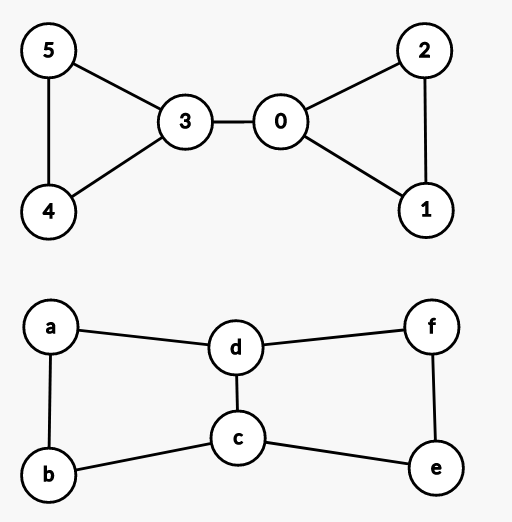

To show that it is more powerful, consider a simple example of graph 1, given by 2 triangles connected with an edge, and graph 2, with 2 squares sharing an edge. The unaugmented version cannot distinguish the graphs because the "middle" nodes have the same computational message passing graphs in both graph 1 and graph 2, and since initially all nodes have the same "colour", the "middle" nodes are represented by the same colour throughout the forward pass of the model. This is also the case with the "corner" nodes. 

With the augmented version, the nodes inside triangles are coloured differently than nodes which are not inside triangles, so that they are initialised with different colours from the beginning, and by injectivity the colours remain different and so by the assumed injectivity of pooling the graphs are found to be different by the augmented model.